In [1]:
# first quick look at the data from test monolith run

In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300
import os

In [66]:
overDF = pd.read_csv('./output/monolithTestDOS4.CSV')
oldDF = pd.read_csv('./output/monolithTestDOS3.CSV')

noMagDF = pd.read_csv('./output/noMagDOS2.CSV')

In [67]:
overDF

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260409_002300_000,1380.000,0.0,NaN,0.0,NaN,892
1,260409_002300_437,1380.437,0.0,NaN,0.0,NaN,886
2,260409_002300_536,1380.536,0.0,NaN,0.0,NaN,895
3,260409_002300_636,1380.636,0.0,NaN,0.0,NaN,900
4,260409_002300_736,1380.736,0.0,NaN,0.0,NaN,899
...,...,...,...,...,...,...,...
9931,260409_003934_900,2374.900,0.0,NaN,0.0,NaN,889
9932,260409_003935_000,2375.000,0.0,NaN,0.0,NaN,901
9933,260409_003935_100,2375.100,0.0,NaN,0.0,NaN,892
9934,260409_003935_200,2375.200,0.0,NaN,0.0,NaN,891


In [80]:
overDF['sensor'] = pd.to_numeric(overDF['sensor'], errors='coerce')
# overDF['sensor']

overDF['seconds'] = pd.to_numeric(overDF['seconds'], errors='coerce')

In [81]:
oldDF['sensor'] = pd.to_numeric(oldDF['sensor'], errors='coerce')
# oldDF['sensor']

oldDF['seconds'] = pd.to_numeric(oldDF['seconds'], errors='coerce')

In [82]:
noMagDF['sensor'] = pd.to_numeric(noMagDF['sensor'], errors='coerce')
# noMagDF['sensor']

noMagDF['seconds'] = pd.to_numeric(noMagDF['seconds'], errors='coerce')

In [83]:
noMagSens = np.array(noMagDF['sensor'])
noMagVolt = noMagSens * 5 / 16383
noMagSecs = np.array(noMagDF['seconds'])

In [84]:
overSens = np.array(overDF['sensor'])

overSecs = np.array(overDF['seconds'])

In [85]:
oldSens = np.array(oldDF['sensor'])

oldSecs = np.array(oldDF['seconds'])

In [86]:
# overSens = overSens[100:1450]
# overSecs = overSecs[100:1450]

In [87]:
overVolt = overSens * 5 / 16383
oldVolt = oldSens * 5 / 16383

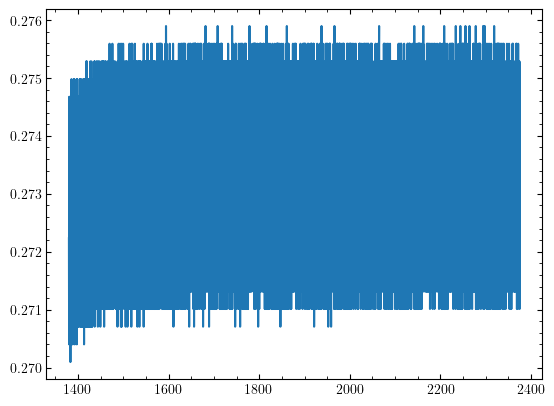

In [89]:
plt.plot(overSecs,overVolt)

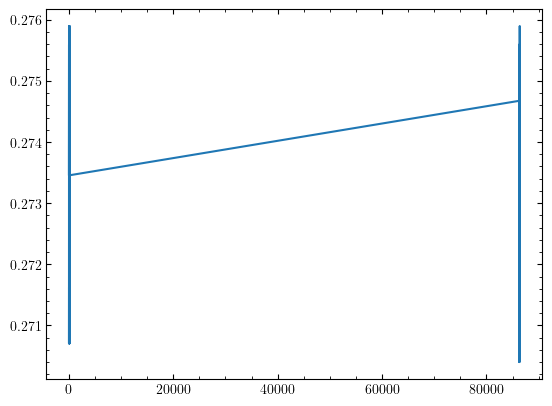

In [90]:
plt.plot(oldSecs,oldVolt)

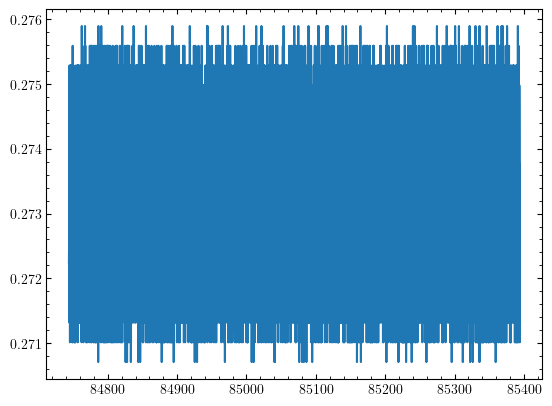

In [91]:
plt.plot(noMagSecs,noMagVolt)
# plt.xlim(81550,81700)

In [99]:
noMagF,noMagPSD = sp.signal.welch(noMagVolt,fs=100,nperseg=300)

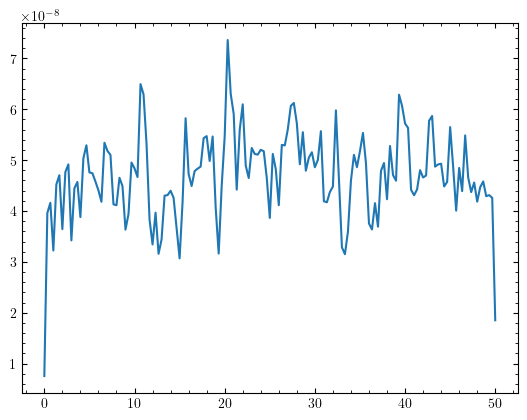

In [100]:
plt.plot(noMagF,noMagPSD)
# plt.semilogy()

In [94]:
overF,overPSD = sp.signal.welch(overVolt,fs=100,nperseg=150)

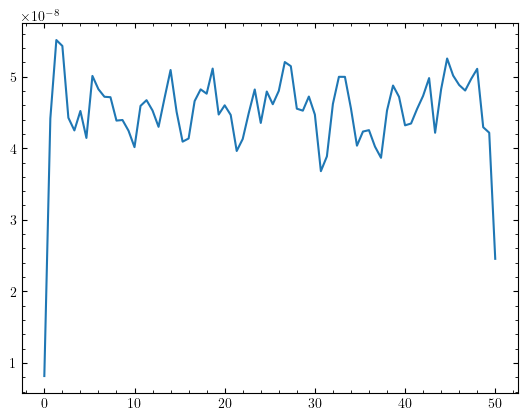

In [95]:
plt.plot(overF,overPSD)

In [96]:
oldF,oldPSD = sp.signal.welch(oldVolt,fs=100,nperseg=300)

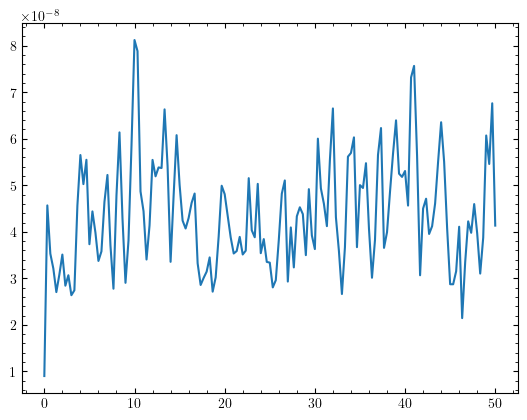

In [97]:
plt.plot(oldF,oldPSD)

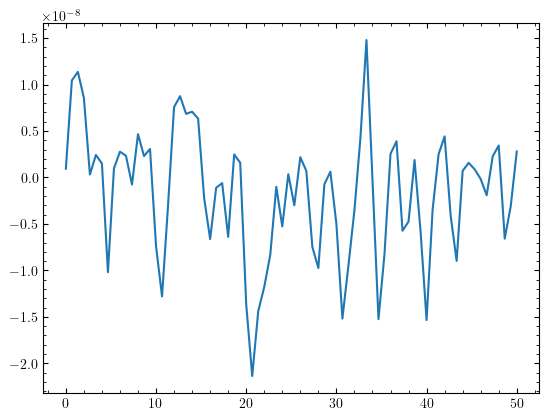

In [98]:
plt.plot(overF,(overPSD-noMagPSD))

In [19]:
shortOverSecs = overSecs[3000:6000]
shortOverVolt = overVolt[3000:6000]

shortNoMagSecs = noMagSecs[3000:6000]
shortNoMagVolt = noMagVolt[3000:6000]

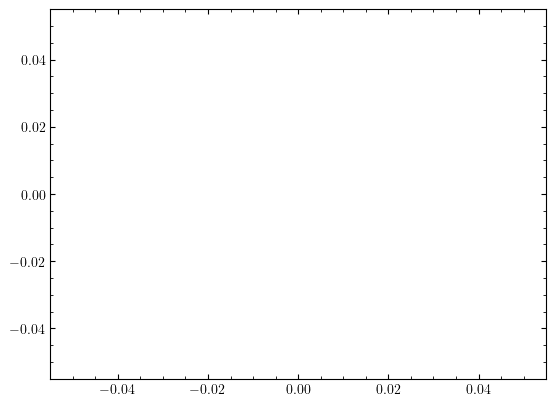

In [20]:
plt.plot(shortOverSecs,shortOverVolt)

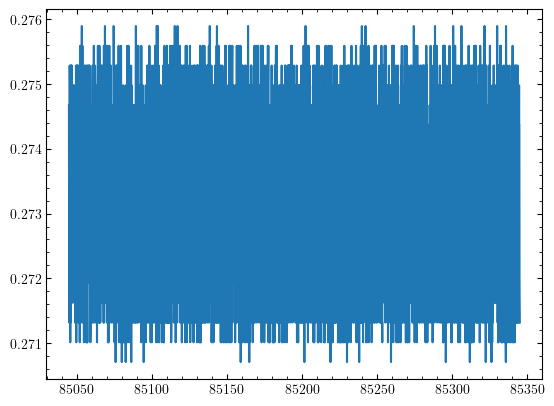

In [21]:
plt.plot(shortNoMagSecs,shortNoMagVolt)

In [22]:
shortOverF,shortOverPSD = sp.signal.welch(shortOverVolt,fs=100,nperseg=200)
shortNoMagF,shortNoMagPSD = sp.signal.welch(shortNoMagVolt,fs=100,nperseg=200)

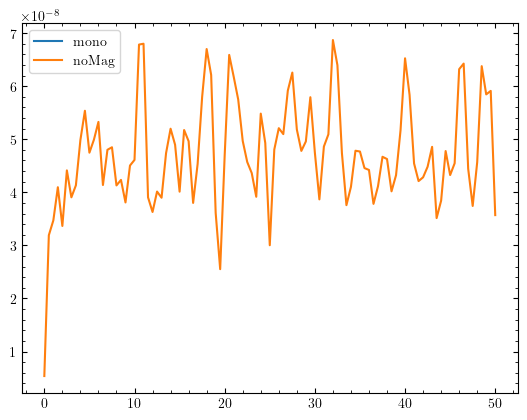

In [23]:
plt.plot(shortOverF,shortOverPSD,label='mono')
plt.plot(shortNoMagF,shortNoMagPSD,label='noMag')
plt.legend()

ValueError: x and y must have same first dimension, but have shapes (0,) and (151,)

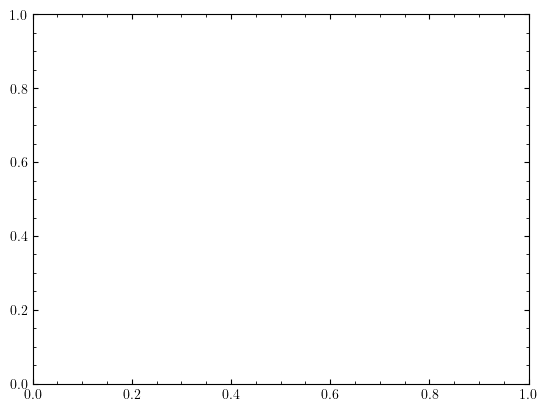

In [ ]:
plt.plot(shortOverF,np.log10(shortOverPSD/shortNoMagPSD))
plt.hlines(0,0,50)